# Initial conditions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/02-initial-conditions.ipynb)

This tutorial shows each initial-condition family accepted by `Kerr.orbit`:

- classical elements;
- Cartesian positions with coordinate velocities;
- spherical positions with coordinate velocities;
- Boyer–Lindquist positions with coordinate velocities;
- bound Kerr parameters `(p, e, x)`.

Exactly one family may be supplied per orbit, and omitted velocity components default to zero.

In [ ]:
%pip install -Uq relatipy

In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import G

import relatipy as rp

## 1. A reference black hole

All examples use the same black hole. Velocities in the Cartesian, spherical and Boyer–Lindquist families are derivatives with respect to coordinate time $t$. For reference we compute a Newtonian circular speed $v_c = \sqrt{G M / r_0}$ and the matching angular velocity at $r_0 = 10\,r_s$, where $r_s = 2GM/c^2$ is the Schwarzschild radius. Lengths are given in kilometres, so the figures use kilometres too.

In [2]:
bh = rp.Kerr(mass=10 * u.Msun, spin=0.7)
r0 = (10 * bh.r_s).to(u.km)
v_c = np.sqrt(G * bh.mass / r0).to(u.km / u.s)
omega_c = (v_c / r0 * u.rad).to(u.rad / u.ms)
print("r0      =", r0)
print("v_c     =", v_c)
print("omega_c =", omega_c)

r0      = 295.32500761002495 km
v_c     = 67035.63152297506 km / s
omega_c = 0.22698935002312856 rad / ms


A small helper prints the orbit's starting point. Before any integration, the position and velocity properties of an orbit (`xyz`, `vxyz`, `R`, `r`, `Theta`, `ut`, ...) describe the point it was built from. `R` is the Boyer–Lindquist radius; `r` is the Euclidean radius of the oblate Cartesian position.

In [1]:
def show(orbit):
    print("xyz  [km]  :", np.round(orbit.xyz.to_value(u.km), 3))
    print("vxyz [km/s]:", np.round(orbit.vxyz.to_value(u.km / u.s), 1))
    print(f"R           = {(orbit.R / bh.r_s).decompose():.4f} r_s")
    print(f"r           = {(orbit.r / bh.r_s).decompose():.4f} r_s")
    print(f"Theta       = {orbit.Theta.to(u.deg):.2f}")
    print(f"u^t         = {orbit.ut:.5f}")

## 2. Classical elements `(a, e, inc, Omega, omega, f)`

Passing the semi-major axis `a` selects this family. `e` is dimensionless and the four angles default to zero. The angles use a right-handed Cartesian frame centred on the black hole with $z$ along the spin axis. With `f = 0` the particle starts at periapsis, $a(1 - e) = 7\,r_s$ in Euclidean radius.

In [4]:
orb_kepler = bh.orbit(a=r0, e=0.3, inc=30 * u.deg, Omega=40 * u.deg,
                      omega=60 * u.deg, f=0 * u.deg)
show(orb_kepler)
el = orb_kepler.orbital_elements()
print("recovered elements:")
print("  a   =", (el.a / bh.r_s).decompose(), "r_s")
print("  e   =", round(el.e, 12))
print("  inc =", el.inc.to(u.deg))

xyz  [km]  : [-20.48  185.213  89.516]
vxyz [km/s]: [-86032.7 -20551.3  22838.5]
R           = 6.9929 r_s
r           = 7.0000 r_s
Theta       = 64.31 deg
u^t         = 1.14112
recovered elements:
  a   = 10.0 r_s
  e   = 0.3
  inc = 29.999999999999996 deg


## 3. Cartesian position and velocity

Any of `x`, `y`, `z` selects the Cartesian family; missing components default to zero. Positions are in the spin-aligned oblate Cartesian axes and `vx`, `vy`, `vz` are coordinate-time velocities.

In [5]:
orb_cart = bh.orbit(x=r0, vy=v_c)
show(orb_cart)

xyz  [km]  : [295.325   0.      0.   ]
vxyz [km/s]: [    0.  67035.6     0. ]
R           = 9.9939 r_s
r           = 10.0000 r_s
Theta       = 90.00 deg
u^t         = 1.08370


## 4. Spherical position and velocity

`r`, `theta` and `phi` are required; `vr`, `vtheta` and `vphi` default to zero. Spherical coordinates are the Euclidean spherical coordinates of the oblate Cartesian position, so this orbit reproduces the Cartesian state above. Angular velocities use angle per time.

In [6]:
orb_sph = bh.orbit(r=r0, theta=90 * u.deg, phi=0 * u.deg, vphi=omega_c)
show(orb_sph)
print("same position as Cartesian:", np.allclose(orb_sph.xyz, orb_cart.xyz))

xyz  [km]  : [295.325   0.      0.   ]
vxyz [km/s]: [    0.  67035.6     0. ]
R           = 9.9939 r_s
r           = 10.0000 r_s
Theta       = 90.00 deg
u^t         = 1.08370
same position as Cartesian: True


## 5. Boyer–Lindquist position and velocity

`R`, `Theta` and `Phi` are required; `vR`, `vTheta` and `vPhi` default to zero. The initial `R` must exceed the outer horizon. For nonzero spin the Boyer–Lindquist `R` differs from the spherical `r`: in the equatorial plane $r = \sqrt{R^2 + a^2}$, where the Kerr parameter is $a = \chi\,r_s/2$ for spin $\chi$, so the same numbers give a slightly larger Cartesian radius than above.

In [7]:
orb_bl = bh.orbit(R=r0, Theta=90 * u.deg, Phi=0 * u.deg, vPhi=omega_c)
show(orb_bl)
a = bh.spin * bh.r_s / 2
print("sqrt(R^2 + a^2) =", (np.sqrt(r0**2 + a**2) / bh.r_s).decompose(), "r_s")

xyz  [km]  : [295.506   0.      0.   ]
vxyz [km/s]: [    0.  67076.7     0. ]
R           = 10.0000 r_s
r           = 10.0061 r_s
Theta       = 90.00 deg
u^t         = 1.08370
sqrt(R^2 + a^2) = 10.006123125366788 r_s


## 6. Bound Kerr parameters `(p, e, x)`

Passing `p` selects the bound Kerr family, which describes a stable bound geodesic. Its parameters are:

- `p`, the semilatus rectum as a length;
- `e` in $[0, 1)$, the eccentricity;
- `x` in $[-1, 1]$, the dimensionless inclination parameter (positive prograde, negative retrograde, $|x| = 1$ equatorial, $x = 0$ polar).

With `p`, `x` is **not** a Cartesian coordinate. The optional phases `q_r0`, `q_theta0` and `q_phi0` (default zero) are Mino-time phases, not Keplerian anomalies:

- `q_r0 = 0` is the inner radial turning point $R = p / (1 + e)$;
- `q_theta0 = 0` is the northern polar turning point;
- `q_phi0` is the initial Boyer–Lindquist azimuth.

The same parameters can also be grouped in an object; see {doc}`../reference/coordinates`.

In [8]:
orb_bound = bh.orbit(p=(6 * bh.r_s).to(u.km), e=0.3, x=0.7)
show(orb_bound)
print("p / (1 + e) =", 6 / 1.3, "r_s")

xyz  [km]  : [95.687  0.    97.34 ]
vxyz [km/s]: [     0.  105575.4      0. ]
R           = 4.6154 r_s
r           = 4.6219 r_s
Theta       = 44.43 deg
u^t         = 1.22359
p / (1 + e) = 4.615384615384615 r_s


Stability is checked by the native constructor, so marginal or unstable parameters raise `ValueError`.

In [9]:
try:
    bh.orbit(p=2 * bh.r_s, e=0.3, x=0.7)
except ValueError as err:
    print("ValueError:", err)

ValueError: bound Kerr parameters must define a stable exterior orbit within the Boyer-Lindquist chart (native status 3)


## 7. Invalid combinations

Mixing two families, or starting inside the outer horizon, raises `ValueError`.

In [10]:
for kwargs in (dict(x=r0, r=r0),
               dict(R=0.75 * bh.r_s, Theta=90 * u.deg, Phi=0 * u.deg)):
    try:
        bh.orbit(**kwargs)
    except ValueError as err:
        print("ValueError:", err)

ValueError: incompatible initial-condition families: cartesian, spherical
ValueError: initial Kerr state is invalid (native status 3)


## 8. Comparing the families

We integrate each orbit for one Keplerian period of the $r_0 = 10\,r_s$ circle, given by `orb_cart.get_keplerian_period()`, and draw the $x$–$y$ projections of all of them in one figure with `rp.plot_sols`:

- the Cartesian and spherical orbits coincide;
- the Boyer–Lindquist one starts slightly farther out;
- the inclined Keplerian and bound Kerr orbits leave the equatorial plane, so only their projections are shown.

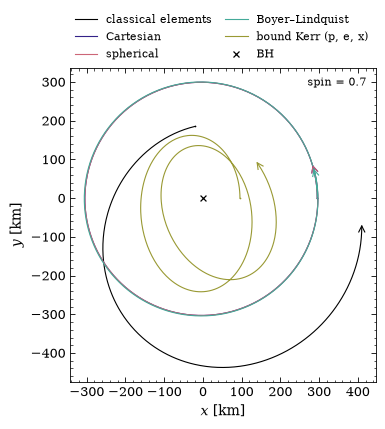

In [11]:
period = orb_cart.get_keplerian_period().to(u.ms)
taus = np.linspace(0, 1, 400) * period
orbits = {
    "classical elements": orb_kepler,
    "Cartesian": orb_cart,
    "spherical": orb_sph,
    "Boyer–Lindquist": orb_bl,
    "bound Kerr (p, e, x)": orb_bound,
}

solutions = [orbit.solve(tau_eval=taus) for orbit in orbits.values()]
fig, ax = rp.plot_sols(*solutions, projection="xy", labels=list(orbits))

## Next steps

- [Getting started](01-getting-started.ipynb): the basic workflow.
- [Integration controls](03-integration-controls.ipynb): methods, tolerances and outcomes.
- [Solutions and states](04-solutions-and-states.ipynb): views, indexing and interpolation.
- API reference: {doc}`../reference/coordinates` and {doc}`../reference/metrics`.